In [4]:
# Import required libraries
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not available")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
# Load the original screenshot metadata
metadata_path = r"C:\Users\Priyanka\OneDrive\Desktop\metadata.csv"

df = pd.read_csv(metadata_path)

print("Total screenshots:", len(df))

print("\nUnique categories:")
print(df["category"].unique())

print("\nScreenshots per category:")
print(df["category"].value_counts())

Total screenshots: 2392

Unique categories:
<StringArray>
['Addresses_Locations',     'Interior_Design',   'Products_Shopping',
      'Receipts_Bills',             'Recipes',    'Tickets_Bookings']
Length: 6, dtype: str

Screenshots per category:
category
Receipts_Bills         433
Interior_Design        413
Addresses_Locations    405
Products_Shopping      391
Recipes                391
Tickets_Bookings       359
Name: count, dtype: int64


In [6]:
# Check a sample of screenshots for format and dimensions
from collections import Counter

formats = []
sizes = []

for path in df["filepath"].head(100):
    try:
        with Image.open(path) as img:
            formats.append(img.format)
            sizes.append(img.size)
    except Exception as e:
        print("Error:", path, e)

print("Image formats:")
print(Counter(formats))

print("\nMost common image sizes:")
print(Counter(sizes).most_common(10))

Image formats:
Counter({'JPEG': 100})

Most common image sizes:
[((738, 1600), 97), ((714, 1599), 3)]


In [7]:
# Split the dataset into:
# 80% training, 10% validation, 10% testing

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["category"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTraining categories:")
print(train_df["category"].value_counts())

Training images: 1913
Validation images: 239
Test images: 240

Training categories:
category
Receipts_Bills         346
Interior_Design        330
Addresses_Locations    324
Products_Shopping      313
Recipes                313
Tickets_Bookings       287
Name: count, dtype: int64


In [8]:
# Convert category names into numerical labels
classes = sorted(df["category"].unique())

class_to_idx = {
    category: index
    for index, category in enumerate(classes)
}

print("Classes:")
print(class_to_idx)


# Training preprocessing and augmentation
# No horizontal flipping because it would mirror screenshot text/UI.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Validation and test images are not augmented.
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nTransforms created successfully.")

Classes:
{'Addresses_Locations': 0, 'Interior_Design': 1, 'Products_Shopping': 2, 'Receipts_Bills': 3, 'Recipes': 4, 'Tickets_Bookings': 5}

Transforms created successfully.


In [9]:
# Custom PyTorch dataset for loading screenshots

class ScreenshotDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_path = self.dataframe.loc[index, "filepath"]
        category = self.dataframe.loc[index, "category"]

        # Load image and convert to RGB
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing/augmentation
        if self.transform:
            image = self.transform(image)

        # Convert category name to numerical label
        label = class_to_idx[category]

        return image, label


# Create datasets
train_dataset = ScreenshotDataset(
    train_df,
    transform=train_transform
)

val_dataset = ScreenshotDataset(
    val_df,
    transform=eval_transform
)

test_dataset = ScreenshotDataset(
    test_df,
    transform=eval_transform
)

print("Datasets created successfully!")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Datasets created successfully!
Train: 1913
Validation: 239
Test: 240


In [10]:
# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# Use 4,000 training samples per epoch.
# Samples may repeat, but augmentation creates different variations.
train_sampler = RandomSampler(
    train_dataset,
    replacement=True,
    num_samples=4000
)


# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=train_sampler,
    num_workers=0,
    pin_memory=True
)


# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


print("\nDataLoaders created!")
print("Training samples per epoch:", len(train_loader.sampler))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Training batches:", len(train_loader))

Using device: cuda

DataLoaders created!
Training samples per epoch: 4000
Validation samples: 239
Test samples: 240
Training batches: 125


In [11]:
# CNN model for classifying screenshots into 6 categories

class ScreenshotCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        # Convolution block 1
        self.conv1 = nn.Conv2d(
            3, 32, kernel_size=3, padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)

        # Convolution block 2
        self.conv2 = nn.Conv2d(
            32, 64, kernel_size=3, padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)

        # Convolution block 3
        self.conv3 = nn.Conv2d(
            64, 128, kernel_size=3, padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        # Convolution block 4
        self.conv4 = nn.Conv2d(
            128, 256, kernel_size=3, padding=1
        )
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        # Reduces feature map to 1 × 1
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = self.pool(
            F.relu(self.bn1(self.conv1(x)))
        )

        x = self.pool(
            F.relu(self.bn2(self.conv2(x)))
        )

        x = self.pool(
            F.relu(self.bn3(self.conv3(x)))
        )

        x = self.pool(
            F.relu(self.bn4(self.conv4(x)))
        )

        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(
            F.relu(self.fc1(x))
        )

        x = self.fc2(x)

        return x


# Create model and move it to GPU
model = ScreenshotCNN(
    num_classes=len(classes)
).to(device)

print("CNN model created successfully!")
print("Model device:", device)

CNN model created successfully!
Model device: cuda


In [12]:
# CrossEntropyLoss is suitable for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Maximum number of epochs
num_epochs = 15

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", num_epochs)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001
Epochs: 15


In [13]:
import time
import copy

# Variables used to store the best model and training history
best_val_loss = float("inf")
best_model_weights = None

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Stop if validation loss does not improve for 3 epochs
patience = 3
patience_counter = 0


def train_model():

    global best_val_loss
    global best_model_weights
    global patience_counter

    start_time = time.time()

    for epoch in range(num_epochs):

        # ==============================
        # TRAINING
        # ==============================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_accuracy = (
            100 * correct / total
        )

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)


        # ==============================
        # VALIDATION
        # ==============================
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += (
                    loss.item() * images.size(0)
                )

                _, predicted = torch.max(
                    outputs, 1
                )

                val_total += labels.size(0)

                val_correct += (
                    predicted == labels
                ).sum().item()

        epoch_val_loss = (
            val_running_loss / val_total
        )

        epoch_val_accuracy = (
            100 * val_correct / val_total
        )

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)


        # ==============================
        # PRINT RESULTS
        # ==============================
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_accuracy:.2f}%",
            flush=True
        )


        # ==============================
        # SAVE BEST MODEL IN MEMORY
        # ==============================
        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

            print(
                "✓ Best model updated",
                flush=True
            )

        else:

            patience_counter += 1

            print(
                f"No improvement. "
                f"Patience: {patience_counter}/{patience}",
                flush=True
            )

            if patience_counter >= patience:

                print(
                    "\nEarly stopping activated!",
                    flush=True
                )

                break


    # ==============================
    # RESTORE BEST MODEL
    # ==============================
    if best_model_weights is not None:

        model.load_state_dict(
            best_model_weights
        )

        # Save the trained CNN
        model_path = (
            r"C:\Users\Priyanka\OneDrive\Desktop"
            r"\screenshot_cnn.pth"
        )

        torch.save(
            best_model_weights,
            model_path
        )

        print(
            f"✓ Best model saved to:\n{model_path}",
            flush=True
        )


    total_time = time.time() - start_time

    print(
        "\n========== TRAINING COMPLETED =========="
    )

    print(
        "Time taken:",
        round(total_time / 60, 2),
        "minutes"
    )

    print(
        "Best validation loss:",
        round(best_val_loss, 4)
    )

In [14]:
train_model()

Epoch [1/15] | Train Loss: 0.9422 | Train Acc: 66.12% | Val Loss: 1.0988 | Val Acc: 56.90%
✓ Best model updated
Epoch [2/15] | Train Loss: 0.5931 | Train Acc: 77.05% | Val Loss: 0.6926 | Val Acc: 71.13%
✓ Best model updated
Epoch [3/15] | Train Loss: 0.5422 | Train Acc: 78.70% | Val Loss: 0.6782 | Val Acc: 68.62%
✓ Best model updated
Epoch [4/15] | Train Loss: 0.4623 | Train Acc: 81.50% | Val Loss: 0.4371 | Val Acc: 80.75%
✓ Best model updated
Epoch [5/15] | Train Loss: 0.4298 | Train Acc: 82.62% | Val Loss: 0.5090 | Val Acc: 78.66%
No improvement. Patience: 1/3
Epoch [6/15] | Train Loss: 0.3938 | Train Acc: 83.83% | Val Loss: 0.8760 | Val Acc: 69.87%
No improvement. Patience: 2/3
Epoch [7/15] | Train Loss: 0.3750 | Train Acc: 84.67% | Val Loss: 0.5262 | Val Acc: 79.92%
No improvement. Patience: 3/3

Early stopping activated!
✓ Best model saved to:
C:\Users\Priyanka\OneDrive\Desktop\screenshot_cnn.pth

========== TRAINING COMPLETED ==========
Time taken: 27.84 minutes
Best validation l

In [15]:
# CNN Evaluation on Test Dataset

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total

print("========== CNN TEST RESULTS ==========")
print("Total test images:", total)
print("Correct predictions:", correct)
print("Test Accuracy:", round(test_accuracy, 2), "%")

========== CNN TEST RESULTS ==========
Total test images: 240
Correct predictions: 194
Test Accuracy: 80.83 %


In [16]:
from sklearn.metrics import classification_report

# Convert class numbers back to category names
class_names = classes

print("========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

========== CLASSIFICATION REPORT ==========

                     precision    recall  f1-score   support

Addresses_Locations     0.5532    0.6500    0.5977        40
    Interior_Design     0.9143    0.7619    0.8312        42
  Products_Shopping     0.9286    1.0000    0.9630        39
     Receipts_Bills     0.8913    0.9318    0.9111        44
            Recipes     0.8667    1.0000    0.9286        39
   Tickets_Bookings     0.6800    0.4722    0.5574        36

           accuracy                         0.8083       240
          macro avg     0.8057    0.8027    0.7981       240
       weighted avg     0.8093    0.8083    0.8031       240



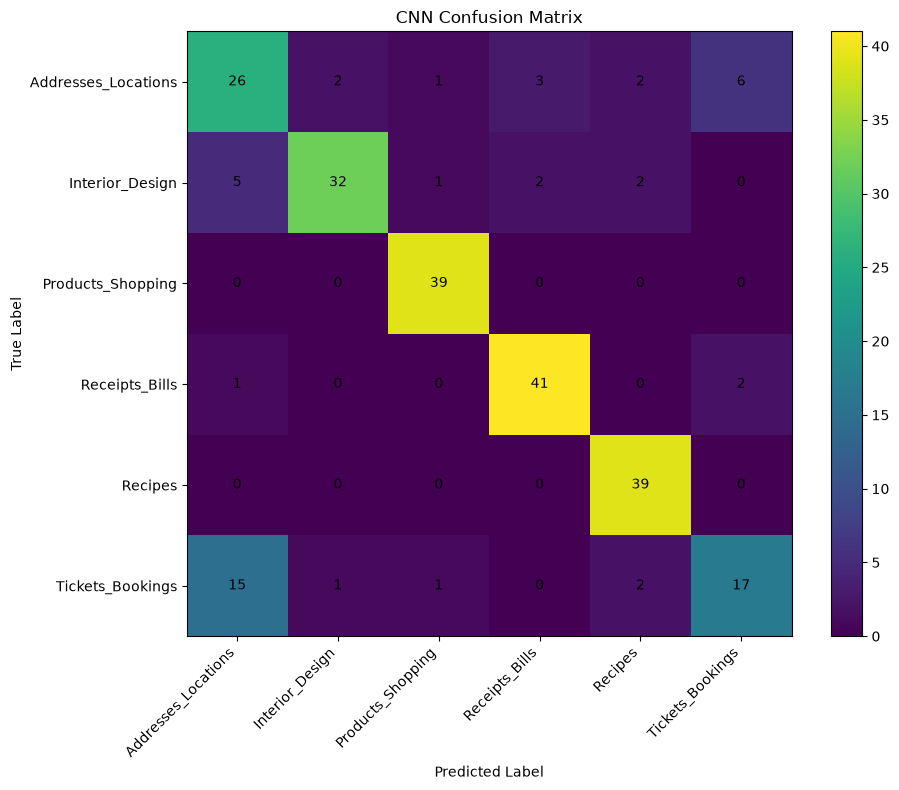

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [18]:
# Save CNN predictions for the test images

import pandas as pd

# Get the corresponding test filenames and paths
cnn_results = test_df[["filename", "category", "filepath"]].copy()

# Add predicted category
cnn_results["predicted_category"] = [
    classes[prediction]
    for prediction in all_predictions
]

# Save to Desktop
output_path = r"C:\Users\Priyanka\OneDrive\Desktop\cnn_results.csv"

cnn_results.to_csv(output_path, index=False)

print("✓ CNN predictions saved successfully!")
print("Location:", output_path)

print("\nFirst 5 results:")
print(cnn_results.head())

✓ CNN predictions saved successfully!
Location: C:\Users\Priyanka\OneDrive\Desktop\cnn_results.csv

First 5 results:
                                               filename             category  \
608                             IMG-20260813-WA1723.jpg      Interior_Design   
235                             IMG-20260813-WA1484.jpg  Addresses_Locations   
1296                            IMG-20260813-WA0371.jpg       Receipts_Bills   
1648  Screenshot_2026-08-13-12-23-41-17_8b1cfbb769bd...              Recipes   
1390                            IMG-20260813-WA0512.jpg       Receipts_Bills   

                                               filepath   predicted_category  
608   C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...      Interior_Design  
235   C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...  Addresses_Locations  
1296  C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...       Receipts_Bills  
1648  C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...              Recipes  
1390  C